# Linear Regression

Linear regression is a fundamental statistical method used to model the relationship between a dependent variable and one or more independent variables. The goal of linear regression is to find the best-fitting line (or hyperplane in higher dimensions) that minimizes the sum of squared differences between the observed values and the predicted values.

## 1. Importing Libraries

In [51]:
%pip install numpy
%pip install matplotlib
%pip install pandas
%pip install scikit-learn

import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer # Filling Missing value with Different Strategy 'mean', 'median', 'mode'
from sklearn.preprocessing import LabelEncoder, StandardScaler # For encoding catagorical variable, IF order is not matter use StandardScaler, else use LabelEncoder
from sklearn.model_selection import train_test_split

## Importing Data set using panadas
dataset = pd.read_csv('../data/02_simple_linear_regression.csv')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Print top 5 rows of the dataset to understand its structure and identify any missing values or anomalies.

In [52]:
dataset.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


Print column names to understand the features available in the dataset and their data types. This will help in identifying which columns are numerical, categorical, or contain missing values that need to be handled before modeling.

In [53]:
print("Column Names and Data Types:")
print(dataset.dtypes)

Column Names and Data Types:
YearsExperience    float64
Salary             float64
dtype: object


In [54]:
dataset.isna().sum()

YearsExperience    0
Salary             0
dtype: int64

In [55]:
dataset.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

There is no Missing Data in the dataset, so we can proceed with modeling without needing to handle any missing values.

Defining X and y for modeling. X will contain the independent variables (features) and y will contain the dependent variable (target).

In [56]:
X = dataset[['YearsExperience']]
y = dataset[['Salary']]
print(X)
print(y)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5
      Salary
0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
5    56642.0
6    60150.0
7    54445.0
8    64445.0
9    57189.0
10   63218.0
11   55794.0
12   56957.0
13   57081.0
14   61111.0
15   67938.0
16   66029.0
17   83088.0
18   81363.0
19   93940.0
20   91738.0
21   98273.0
22  101302.0
23  113812.0
24  109431.0
25  105582.0
26  116969.0
27  112635.0
28 

### 2. Missing Data Handling (Skipped for this dataset)

In [57]:
# Define which columns are numerical and might have missing values
#numeric_cols = ['YearsExperience', 'Salary']

# Create the imputer object
#imputer = SimpleImputer(strategy='mean')

# Fit and transform the specific columns, replacing the old columns in the DataFrame
#X[numeric_cols] = imputer.fit_transform(X[numeric_cols])

#print("X after handling missing values:")
#print(X)

### 3. Transformation of Categorical Variables (Skipped for this dataset)

Both the features and target variable are numerical, so we can proceed with modeling without needing to transform any categorical variables.

In [58]:
# 4.1 One-Hot Encoding for Features
# By default, pd.get_dummies converts to boolean (True/False). 
# Adding astype(int) converts them to 1 and 0.
# X = pd.get_dummies(X, columns=['Country']).astype(int)

# # 4.2 Label Encoding for Target Variable
# label_encoder = LabelEncoder()
# y = label_encoder.fit_transform(y)

# print("X after One-Hot Encoding:")
# print(X.head())
# print("\ny after Label Encoding:")
# print(y)

### 4. Train-Test Split

Splitting the dataset into training and testing sets to evaluate the performance of the linear regression model on unseen data. The training set will be used to fit the model, while the testing set will be used to assess its predictive accuracy.

random_state=0 or 1 mean that the split will be the same every time you run the code, which is useful for reproducibility. You can choose any integer as the random_state, and it will ensure that the same random split of the data is generated each time.

In [59]:
# Perform the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

print("Training Features (X_train):")
print(X_train)

Training Features (X_train):
    YearsExperience
27              9.6
11              4.0
17              5.3
22              7.9
5               2.9
16              5.1
8               3.2
14              4.5
23              8.2
20              6.8
1               1.3
29             10.5
6               3.0
4               2.2
18              5.9
19              6.0
9               3.7
7               3.2
25              9.0
3               2.0
0               1.1
21              7.1
15              4.9
12              4.0


## 5. Model Training

Fitting a linear regression model to the training data to learn the relationship between the independent variables and the dependent variable.

In [60]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

### Calculate b0 and b1

Calculating the coefficients (b0 and b1) for the linear regression model using the least squares method. b0 is the intercept, and b1 is the slope of the line that best fits the data.

In [61]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


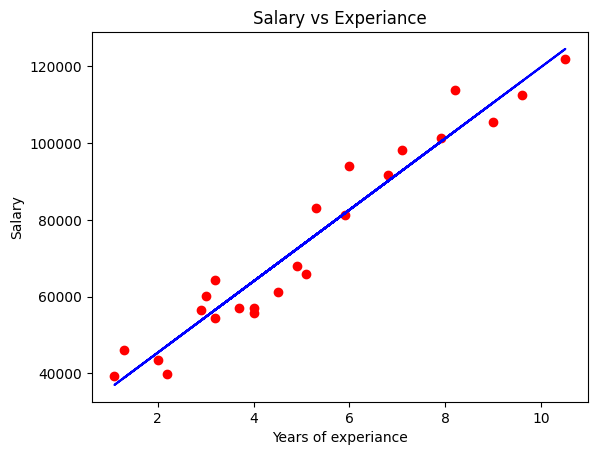

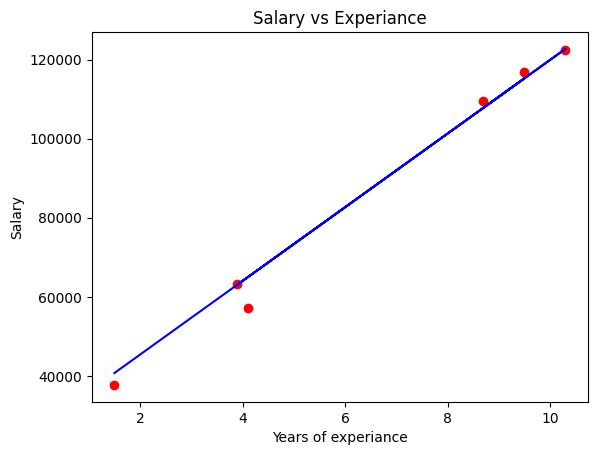

In [62]:
y_hat = lr.predict(X_test)


import matplotlib.pyplot as plt

plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, lr.predict(X_train), color='blue')
plt.title('Salary vs Experiance')
plt.xlabel('Years of experiance')
plt.ylabel('Salary')
plt.show()

plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, lr.predict(X_test), color='blue')
plt.title('Salary vs Experiance')
plt.xlabel('Years of experiance')
plt.ylabel('Salary')
plt.show()



You are creating a **Visualization of your Model's Learning**. In the world of Machine Learning, this is the "Moment of Truth" where you see if your mathematical formulas actually align with reality.

Here is a breakdown of exactly what each line is doing and what the resulting graph tells you:

---

### 1. The Red Dots: "The Ground Truth"
`plt.scatter(X_train, y_train, color='red')`
* **What it does:** This plots your actual raw data points from your training set.
* **The Logic:** The X-axis represents the input (Years of Experience) and the Y-axis represents the actual Salary that person was paid. 
* **Purpose:** These red dots show the "Real World" relationship before the machine tries to guess anything.

### 2. The Blue Dots (or Line): "The Machine's Prediction"
`plt.scatter(X_train, lr.predict(X_train), color='blue')`
* **What it does:** This asks your trained model (`lr`) to look at the same experience levels (`X_train`) and predict what the salary *should* be.
* **The Logic:** Instead of plotting the real salary, you are plotting the **Predicted Salary**.
* **The Visual Result:** Since you are using Linear Regression, these blue points will form a **perfectly straight line**. This is because the model has learned a linear equation ($y = wx + b$).



### 3. The Labels: "Context"
`plt.title('Salary vs Experience')`, `plt.xlabel(...)`, `plt.ylabel(...)`
* **What it does:** This provides the metadata. 
* **The Logic:** Without these, your graph is just dots on a grid. In a professional setting, a model is only as good as your ability to explain it to stakeholders.

---

### What to Look For in the Result
When you run `plt.show()`, you will see how close the blue points are to the red points:

1.  **High Accuracy:** If the blue line passes directly through the middle of the red dots, your model has "captured the trend" well.
2.  **The Residuals:** The vertical distance between a red dot (Actual) and the blue line (Predicted) is called the **Error** or **Residual**. 
3.  **The Goal:** Mastering ML is essentially the art of minimizing the distance between those red dots and that blue line.

---

### A "Master" Tip for Visualization
Usually, for Linear Regression, we don't use `plt.scatter` for the predictions. Instead, we use `plt.plot`:

```python
# Use a line instead of dots for predictions to show the "Trend Line"
plt.plot(X_train, lr.predict(X_train), color='blue')
```

This makes it much easier to distinguish between the **Actual Data (Dots)** and the **Model's Logic (The Line)**.

### Model Evaluation

Evaluating the performance of the linear regression model using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R-squared (R²) to understand how well the model fits the data and how accurately it predicts the target variable.
